In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

### Reading the data

In [2]:
df = pd.read_csv("bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## EDA (Data Analysis)

In [3]:
df.shape

(45211, 17)

In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [11]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [7]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
45206    False
45207    False
45208    False
45209    False
45210    False
Length: 45211, dtype: bool

### Inference: No null values or duplicate values exist.

In [ ]:
#All the unique values in each feature

for i in df.columns:
    print( "The column name:", i, "\n" ,"the unique values are",  df[i].unique(), "\n")
    

The column name: age 
 the unique values are [58 44 33 47 35 28 42 43 41 29 53 57 51 45 60 56 32 25 40 39 52 46 36 49
 59 37 50 54 55 48 24 38 31 30 27 34 23 26 61 22 21 20 66 62 83 75 67 70
 65 68 64 69 72 71 19 76 85 63 90 82 73 74 78 80 94 79 77 86 95 81 18 89
 84 87 92 93 88] 

The column name: job 
 the unique values are ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student'] 

The column name: marital 
 the unique values are ['married' 'single' 'divorced'] 

The column name: education 
 the unique values are ['tertiary' 'secondary' 'unknown' 'primary'] 

The column name: default 
 the unique values are ['no' 'yes'] 

The column name: balance 
 the unique values are [ 2143    29     2 ...  8205 14204 16353] 

The column name: housing 
 the unique values are ['yes' 'no'] 

The column name: loan 
 the unique values are ['no' 'yes'] 

The column name: contact 
 the unique values are ['unknow

In [ ]:
#Value counts in each feature
for i in df.columns:
    print("The column name is:", i,"\n", df[i].value_counts(),"\n")
    

The column name is: age 
 age
32    2085
31    1996
33    1972
34    1930
35    1894
      ... 
93       2
90       2
95       2
88       2
94       1
Name: count, Length: 77, dtype: int64 

The column name is: job 
 job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64 

The column name is: marital 
 marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64 

The column name is: education 
 education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64 

The column name is: default 
 default
no     44396
yes      815
Name: count, dtype: int64 

The column name is: balance 
 balance
 0        3514
 1         195
 2         156
 4         139
 3         134
          ... 
-

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

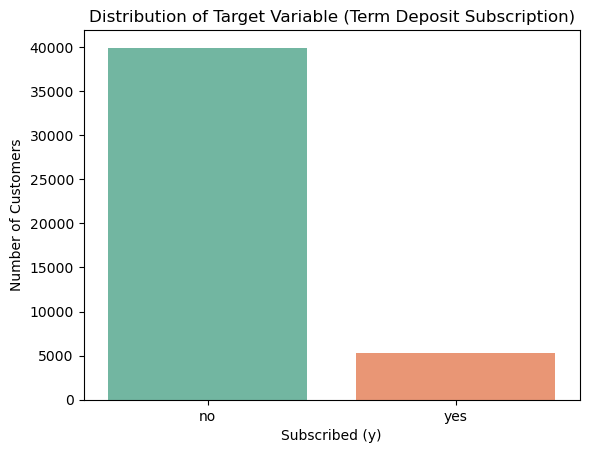

In [ ]:
# Plot 1:Class Distribution
sns.countplot(x='y', data=df, order=df['y'].value_counts().index, hue='y', legend=False, palette='Set2')
plt.title('Distribution of Target Variable (Term Deposit Subscription)')
plt.xlabel('Subscribed (y)')
plt.ylabel('Number of Customers')

# The percentage 
df['y'].value_counts(normalize=True) * 100

Text(0, 0.5, 'Frequency')

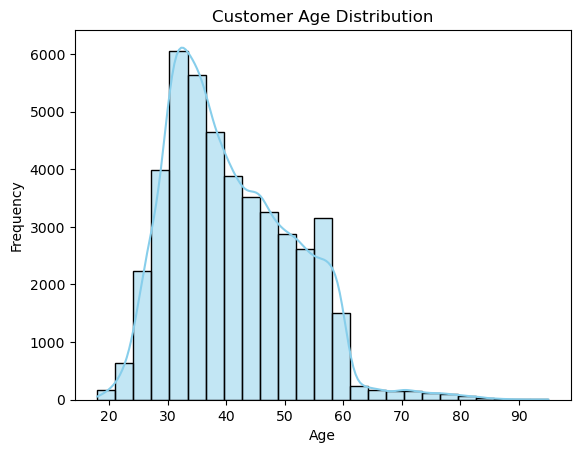

In [30]:
# Plot 2
sns.histplot(x='age', data=df, bins=25, kde=True, color='skyblue')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

C:\Users\91966\AppData\Local\Temp\ipykernel_3144\3227593258.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rate', y='job', data=job_stats, palette='coolwarm')


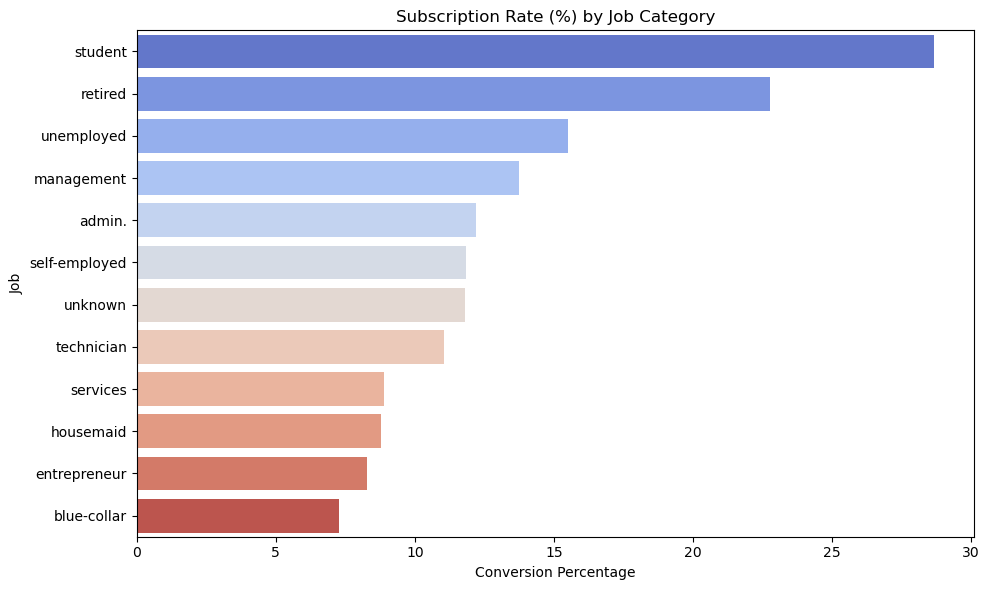

In [15]:
#Subscription Rate (%) by Job Category

df['rate'] = df['y'].map({'yes': 1, 'no': 0}) * 100
job_stats = df.groupby('job')['rate'].mean().reset_index().sort_values('rate', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='rate', y='job', data=job_stats, palette='coolwarm')

plt.title('Subscription Rate (%) by Job Category')
plt.xlabel('Conversion Percentage')
plt.ylabel('Job')
plt.tight_layout()
plt.show()

## Independent and dependent features

In [5]:
X=df.drop(["y","duration"],axis=1)  #Duration column not needed.
y=df["y"]
y = y.map({'yes': 1, 'no': 0})  #Encoding y here only

## Train Test Split

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.3, random_state=42)

In [7]:
numerical_cols = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous'] # duration dropped
nominal_cols = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'poutcome']
ordinal_cols = ['education', 'month']

## Data Encoding and Stanrdization

In [8]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

scaler=StandardScaler()
OHE = OneHotEncoder(drop='first')   #The first column of OneHotEncoder is always a waste
OE=OrdinalEncoder()

preprocessor= ColumnTransformer(
     [
         ("OneHotEncoder", OHE, nominal_cols ),        
          ("OrdinalEncoder",OE,ordinal_cols),
          ("StandardScaler", scaler, numerical_cols)
    ]
)


In [9]:
X_train= preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)

## Training the model

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report

In [ ]:
#Hyperparameter Tuning the models
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "n_estimators": [100, 200, 500, 1000]}

log_reg_params= {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'class_weight': [None, 'balanced']
}

randomcv_models = [
          ["Random Forest", RandomForestClassifier(), rf_params],
          ["Logistic Regression", LogisticRegression(), log_reg_params]
]

from sklearn.model_selection import RandomizedSearchCV
model_param={}

for name, model, params in randomcv_models:
        
        random= RandomizedSearchCV(estimator=model, param_distributions=params,cv=3,verbose=3,scoring='f1')  

        random.fit(X_train, y_train)
        y_pred = random.predict(X_test)
        print(name)
        print(classification_report(y_test, y_pred))
        model_param[name]=random.best_params_ #Making a dictionary of best params with their model

for name in model_param:
    print(name, ":")
    print(model_param[name])

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV 1/3] END .....max_depth=5, n_estimators=500;, score=0.192 total time=   5.0s
[CV 2/3] END .....max_depth=5, n_estimators=500;, score=0.220 total time=   4.7s
[CV 3/3] END .....max_depth=5, n_estimators=500;, score=0.214 total time=   4.6s
[CV 1/3] END ..max_depth=None, n_estimators=100;, score=0.306 total time=   7.2s
[CV 2/3] END ..max_depth=None, n_estimators=100;, score=0.309 total time=  10.5s
[CV 3/3] END ..max_depth=None, n_estimators=100;, score=0.291 total time=  10.2s
[CV 1/3] END .....max_depth=5, n_estimators=200;, score=0.228 total time=   6.8s
[CV 2/3] END .....max_depth=5, n_estimators=200;, score=0.231 total time=   7.0s
[CV 3/3] END .....max_depth=5, n_estimators=200;, score=0.218 total time=   7.3s
[CV 1/3] END ....max_depth=10, n_estimators=500;, score=0.270 total time=  29.2s
[CV 2/3] END ....max_depth=10, n_estimators=500;, score=0.275 total time=  28.3s
[CV 3/3] END ....max_depth=10, n_estimators=500;

## Predicting the test data

In [13]:
y_pred = random.predict(X_test)
y_probs = random.predict_proba(X_test)[:, 1]  # Probability of subscribing ("yes")

X_test_readable = X.loc[y_test.index].copy()

X_test_readable['Predicted_Class'] = y_pred
X_test_readable['Actual_Class'] = y_test.values
X_test_readable['Confidence_Score (%)'] = np.round(y_probs * 100, 2)

predicted_yes = X_test_readable[X_test_readable['Predicted_Class'] == 1]
predicted_no = X_test_readable[X_test_readable['Predicted_Class'] == 0]

# Extracting exactly 3 from "yes" and 2 from "no" 
sample_yes = predicted_yes.tail(3)
sample_no = predicted_no.head(2)
showcase_df = pd.concat([sample_yes, sample_no])

for rank, (idx, customer) in enumerate(showcase_df.iterrows(), 1):
    print(f"(Dataset Index Row: {idx})")
    print("-" * 65)
    print(f" Demographics: {customer['age']} years old | Job: {customer['job']} | Status: {customer['marital']}")
    print(f" Financials  : Balance: {customer['balance']}€ | Housing Loan: {customer['housing']} | Personal Loan: {customer['loan']}")
    print(f" Prediction  : {'SUBSCRIBED (YES)' if customer['Predicted_Class'] == 1 else 'NO SUBSCRIPTION (NO)'}")
    print(f" Probability : {customer['Confidence_Score (%)']}% chance of a positive conversion")
    print(f" Actual Label: {'YES' if customer['Actual_Class'] == 1 else 'NO'}")
    print("=" * 65 + "\n")

(Dataset Index Row: 40925)
-----------------------------------------------------------------
 Demographics: 34 years old | Job: services | Status: married
 Financials  : Balance: 1337€ | Housing Loan: no | Personal Loan: no
 Prediction  : SUBSCRIBED (YES)
 Probability : 91.68% chance of a positive conversion
 Actual Label: YES

(Dataset Index Row: 28462)
-----------------------------------------------------------------
 Demographics: 38 years old | Job: unemployed | Status: single
 Financials  : Balance: 560€ | Housing Loan: no | Personal Loan: no
 Prediction  : SUBSCRIBED (YES)
 Probability : 70.04% chance of a positive conversion
 Actual Label: NO

(Dataset Index Row: 28550)
-----------------------------------------------------------------
 Demographics: 57 years old | Job: management | Status: divorced
 Financials  : Balance: 1016€ | Housing Loan: yes | Personal Loan: no
 Prediction  : SUBSCRIBED (YES)
 Probability : 50.37% chance of a positive conversion
 Actual Label: NO

(Dataset

## Most important features in the dataset

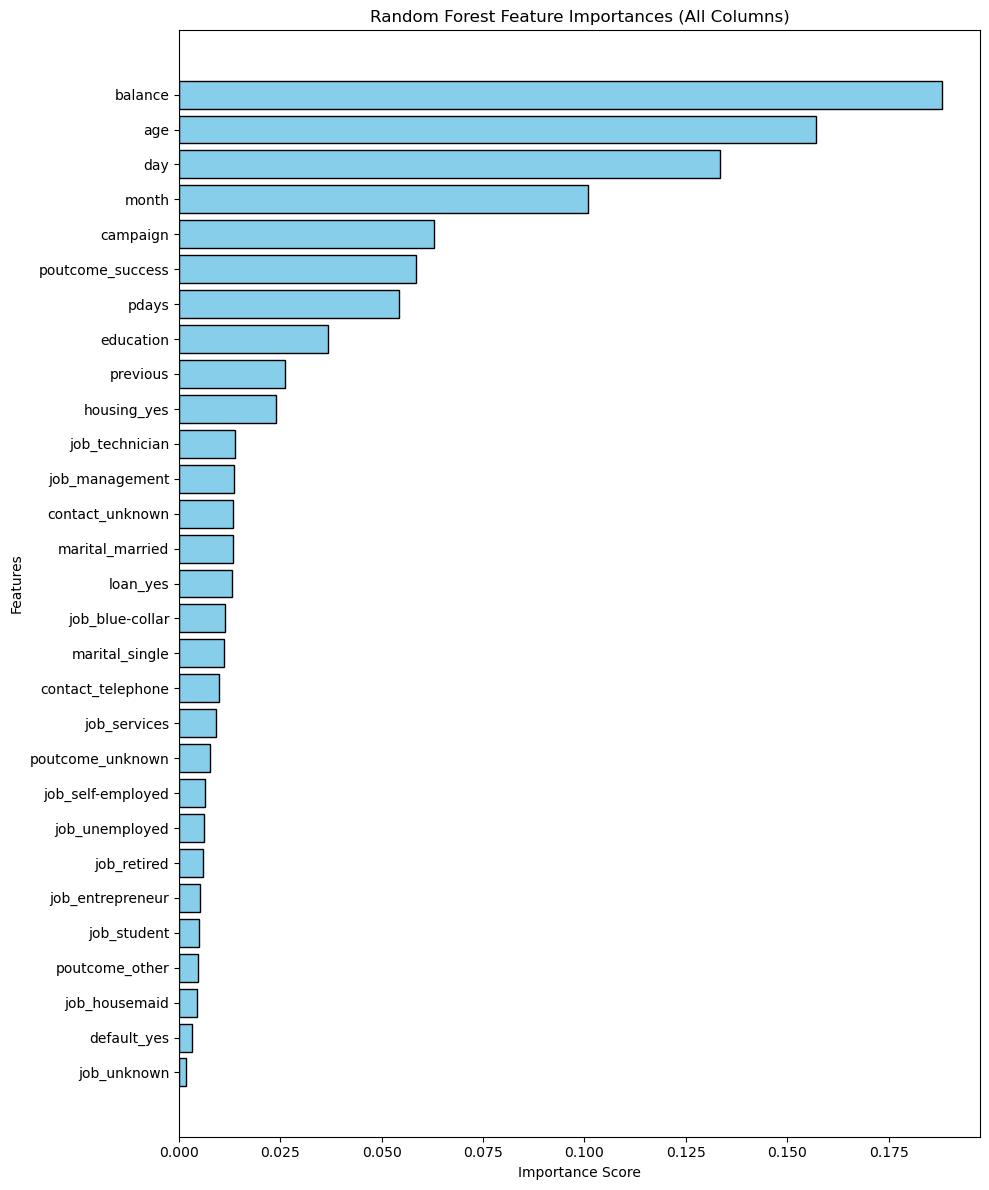

In [14]:
best_rf_params = model_param["Random Forest"]

rf_model = RandomForestClassifier(**best_rf_params, random_state=42)
rf_model.fit(X_train, y_train)

ohe_features = list(preprocessor.named_transformers_['OneHotEncoder'].get_feature_names_out(nominal_cols))
all_features = ohe_features + list(ordinal_cols) + list(numerical_cols)

importances = pd.DataFrame(rf_model.feature_importances_)
importances['feature'] = all_features
importances.columns = ['importance', 'feature']
importances.sort_values(by='importance', ascending=True, inplace=True)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(importances.feature, importances.importance, color='skyblue', edgecolor='black')
ax.set_title("Random Forest Feature Importances (All Columns)")
ax.set_xlabel("Importance Score")
ax.set_ylabel("Features")
plt.tight_layout()
plt.show()